In [1]:
import sys
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from api_ingestion import read_json, clean_data_api

#get path for dataframes
BASE_DIR = Path().resolve().parent  # if inside analysis folder
DATA_PATH = BASE_DIR / "data" / "valid_data.csv"
df = pd.read_csv(DATA_PATH)
DATA_PATH = BASE_DIR / "data" / "unemployment_data_seed.json"
u_df = read_json(DATA_PATH)
u_df = clean_data_api(u_df)
#print(df.dtypes)
print(u_df.dtypes)

state_fips            string
state                 string
date          datetime64[us]
value                float64
dtype: object


In [2]:
df_avg = (
    df.groupby(['indicator', 'group', 'subgroup'])['value']
    .mean()
    .reset_index()
)


In [44]:
df_avg['indicator'].unique()
df_avg['group'].unique()

df.head()

,indicator,group,state,subgroup,phase,time period,time period label,time period start date,time period end date,value,lowci,highci,confidence interval,quartile range
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2.0,15,"Sep 16 - Sep 28, 2020",2020-09-16,2020-09-28,6.9,6.5,7.3,6.5 - 7.3,NaN
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2.0,15,"Sep 16 - Sep 28, 2020",2020-09-16,2020-09-28,11.0,10.4,11.6,10.4 - 11.6,NaN
2,Took Prescription Medication for Mental Health...,National Estimate,United States,United States,2.0,13,"Aug 19 - Aug 31, 2020",2020-08-19,2020-08-31,19.4,19.0,19.8,19.0 - 19.8,NaN
3,Took Prescription Medication for Mental Health...,By Age,United States,18 - 29 years,2.0,13,"Aug 19 - Aug 31, 2020",2020-08-19,2020-08-31,18.7,17.2,20.3,17.2 - 20.3,NaN
4,Took Prescription Medication for Mental Health...,By Age,United States,30 - 39 years,2.0,13,"Aug 19 - Aug 31, 2020",2020-08-19,2020-08-31,18.3,17.3,19.2,17.3 - 19.2,NaN


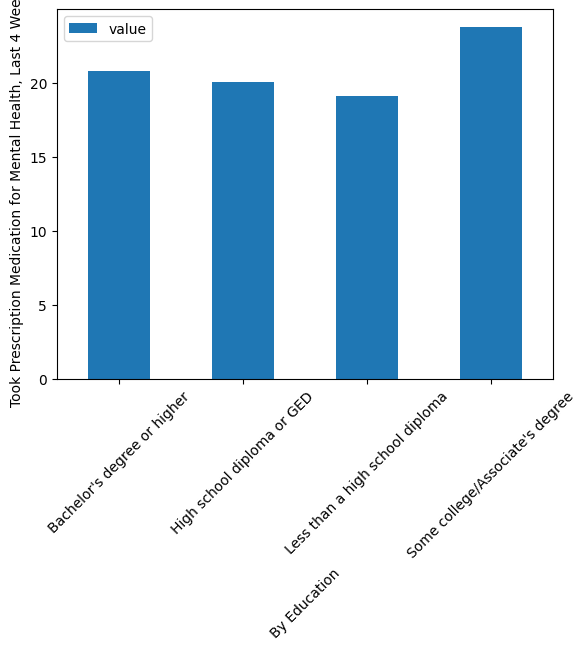

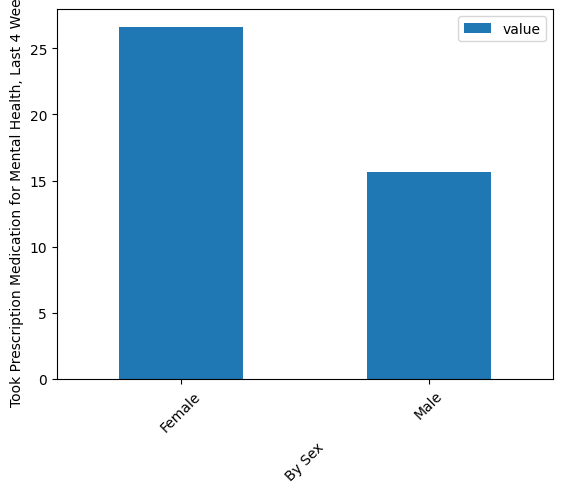

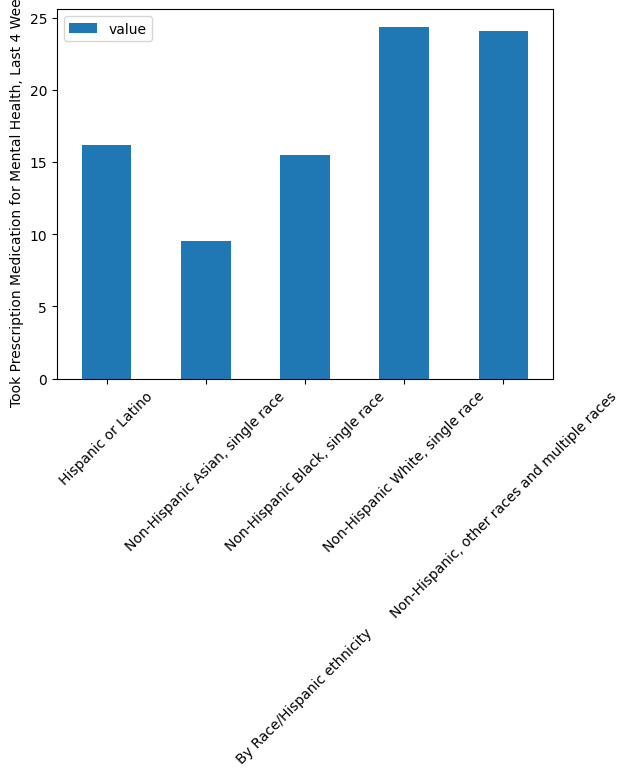

In [39]:
NEED_COUNSELING_BUT_NOT_RECEIVED_INDICATOR = 'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks'
TOOK_PRESCRIPTION_INDICATOR = "Took Prescription Medication for Mental Health, Last 4 Weeks"

def check_indicator(df, indicator = TOOK_PRESCRIPTION_INDICATOR, ascending=True, nlimit = 10):
    df_indicator = df[df['indicator'] == indicator]
    return df_indicator.sort_values(by='value', ascending=ascending).head(10)

def histogram(df, group, indicator = TOOK_PRESCRIPTION_INDICATOR):
    df_group = df[df['indicator'] == indicator]
    df_group = df_group[df_group['group'] == group]
    df_group = df_group[['subgroup','value']]
    df_group = df_group.set_index('subgroup')
    df_group.plot(kind='bar', xlabel= group)
    
    plt.ylabel(indicator)
    plt.xlabel(group,rotation = 45)
    plt.xticks(rotation=45)

    plt.show()

histogram(df_avg, 'By Education')
histogram(df_avg, 'By Sex')
histogram(df_avg, 'By Race/Hispanic ethnicity')

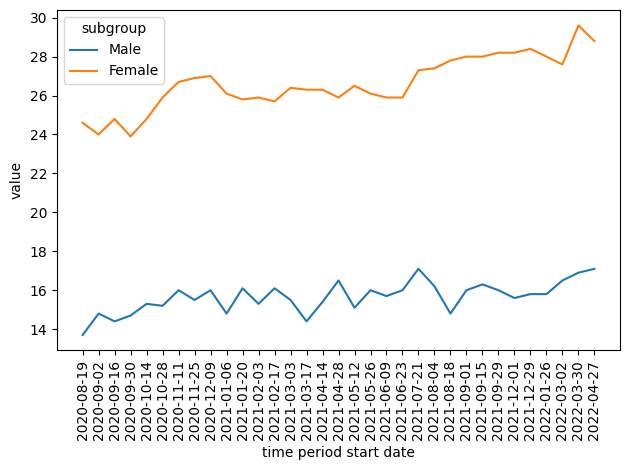

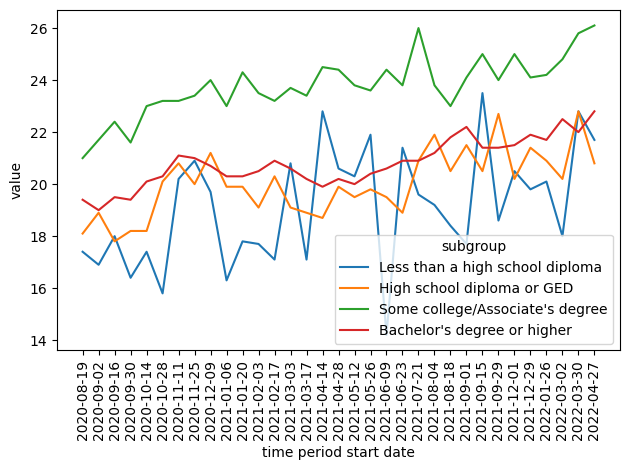

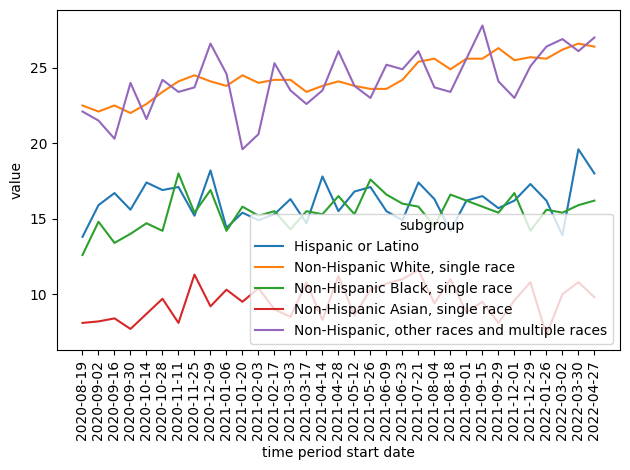

In [55]:
def lineplot(df, group, indicator = TOOK_PRESCRIPTION_INDICATOR):
    df_group = df[df['indicator'] == indicator]
    df_group = df_group[df_group['group'] == group]
    df_group = df_group.set_index('subgroup')

    plot = sns.lineplot(data=df_group, x='time period start date', y='value', hue= 'subgroup')
    plot.tick_params(axis='x', rotation=90)
    plt.tight_layout()

    plt.show()



lineplot(df, 'By Sex')
lineplot(df, 'By Education')
lineplot(df, 'By Race/Hispanic ethnicity')